In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

In [2]:
passenger_df = pd.read_csv("../datasets/processed/cleaned_metro_data.csv")

network_df = pd.read_csv("../datasets/processed/cleaned_metro_network.csv")

In [3]:
passenger_df.head()

,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
0,59771,2022-05-08,Inderlok,Kashmere Gate,12.94,77.99,18.27,13.0,Smart Card,maintenance
1,21363,2023-01-12,Model Town,Dilshad Garden,2.33,35.89,83.71,15.0,Tourist Card,maintenance
2,127325,2023-07-13,Kashmere Gate,Netaji Subhash Place,5.56,64.35,43.70,9.0,Single,off-peak
3,140510,2022-11-10,Chandni Chowk,Hauz Khas,4.02,144.13,14.98,27.0,Unknown,maintenance
4,144298,2022-11-06,Rajiv Chowk,Kalkaji Mandir,9.66,104.96,83.84,23.0,Single,off-peak


In [4]:
network_df.head()

,Station ID,Station Name,Distance from Start (km),Line,Opening Date,Station Layout,Latitude,Longitude
0,1,Jhil Mil,10.3,Red line,2008-04-06,Elevated,28.675790,77.312390
1,2,Welcome [Conn: Red],46.8,Pink line,2018-10-31,Elevated,28.671800,77.277560
2,3,DLF Phase 3,10.0,Rapid Metro,2013-11-14,Elevated,28.493600,77.093500
3,4,Okhla NSIC,23.8,Magenta line,2017-12-25,Elevated,28.554483,77.264849
4,5,Dwarka Mor,10.2,Blue line,2005-12-30,Elevated,28.619320,77.033260


In [5]:
passenger_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   TripID              150000 non-null  int64  
 1   Date                150000 non-null  object 
 2   From_Station        150000 non-null  object 
 3   To_Station          150000 non-null  object 
 4   Distance_km         150000 non-null  float64
 5   Fare                150000 non-null  float64
 6   Cost_per_passenger  150000 non-null  float64
 7   Passengers          150000 non-null  float64
 8   Ticket_Type         150000 non-null  object 
 9   Remarks             150000 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 11.4+ MB


In [6]:
network_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Station ID                285 non-null    int64  
 1   Station Name              285 non-null    str    
 2   Distance from Start (km)  285 non-null    float64
 3   Line                      285 non-null    str    
 4   Opening Date              285 non-null    str    
 5   Station Layout            285 non-null    str    
 6   Latitude                  285 non-null    float64
 7   Longitude                 285 non-null    float64
dtypes: float64(3), int64(1), str(4)
memory usage: 17.9 KB


In [7]:
print(passenger_df.shape)

print(network_df.shape)

(150000, 10)
(285, 8)


In [8]:
print(passenger_df.columns)

print(network_df.columns)

Index(['TripID', 'Date', 'From_Station', 'To_Station', 'Distance_km', 'Fare',
       'Cost_per_passenger', 'Passengers', 'Ticket_Type', 'Remarks'],
      dtype='str')
Index(['Station ID', 'Station Name', 'Distance from Start (km)', 'Line',
       'Opening Date', 'Station Layout', 'Latitude', 'Longitude'],
      dtype='str')


In [9]:
passenger_df.isnull().sum()

TripID                0
Date                  0
From_Station          0
To_Station            0
Distance_km           0
Fare                  0
Cost_per_passenger    0
Passengers            0
Ticket_Type           0
Remarks               0
dtype: int64

In [10]:
network_df.isnull().sum()

Station ID                  0
Station Name                0
Distance from Start (km)    0
Line                        0
Opening Date                0
Station Layout              0
Latitude                    0
Longitude                   0
dtype: int64

In [11]:
passenger_df.duplicated().sum()

np.int64(0)

In [12]:
network_df.duplicated().sum()

np.int64(0)

In [13]:
passenger_df.describe()

,TripID,Distance_km,Fare,Cost_per_passenger,Passengers
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,75000.500000,5.490446,105.116503,62.474807,19.803487
std,43301.414527,4.980333,54.879494,33.207161,4.870934
min,1.000000,0.500000,10.000000,5.000000,0.000000
25%,37500.750000,1.940000,57.570000,33.687500,17.000000
50%,75000.500000,3.960000,105.170000,62.520000,20.000000
75%,112500.250000,7.420000,152.572500,91.190000,23.000000
max,150000.000000,63.030000,200.000000,120.000000,41.000000


In [14]:
network_df.describe()

,Station ID,Distance from Start (km),Latitude,Longitude
count,285.000000,285.000000,285.000000,285.000000
mean,143.000000,19.218947,28.595428,77.029315
std,82.416625,14.002862,0.091316,2.875400
min,1.000000,0.000000,27.920862,28.698807
25%,72.000000,7.300000,28.545828,77.107130
50%,143.000000,17.400000,28.613453,77.207220
75%,214.000000,28.800000,28.666360,77.281165
max,285.000000,52.700000,28.878965,77.554479


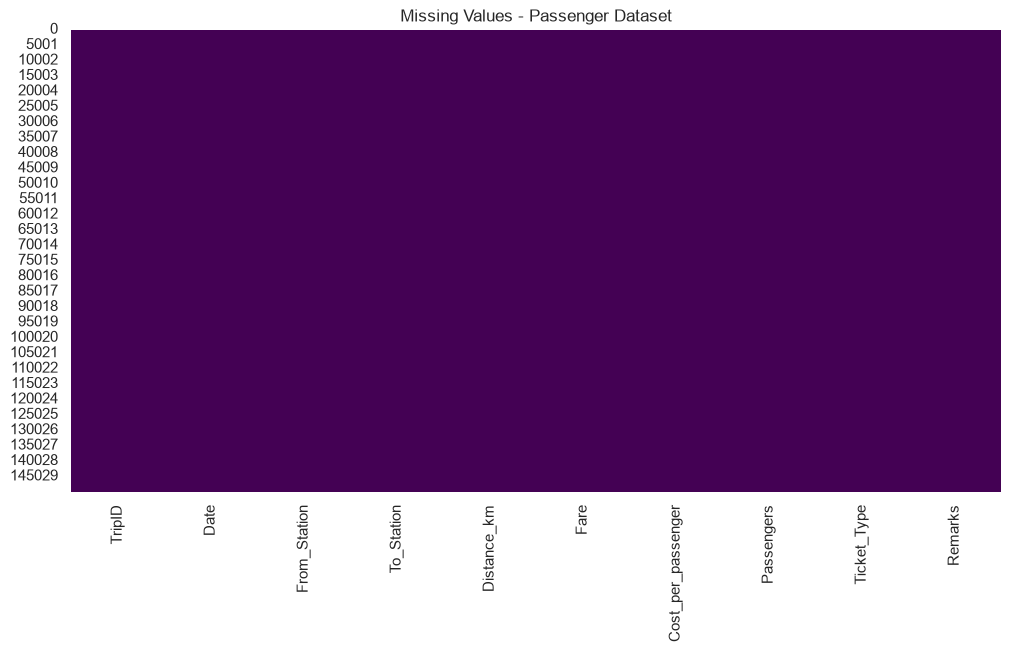

In [6]:
plt.figure(figsize=(12,6))

sns.heatmap(
    passenger_df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values - Passenger Dataset")
plt.show()

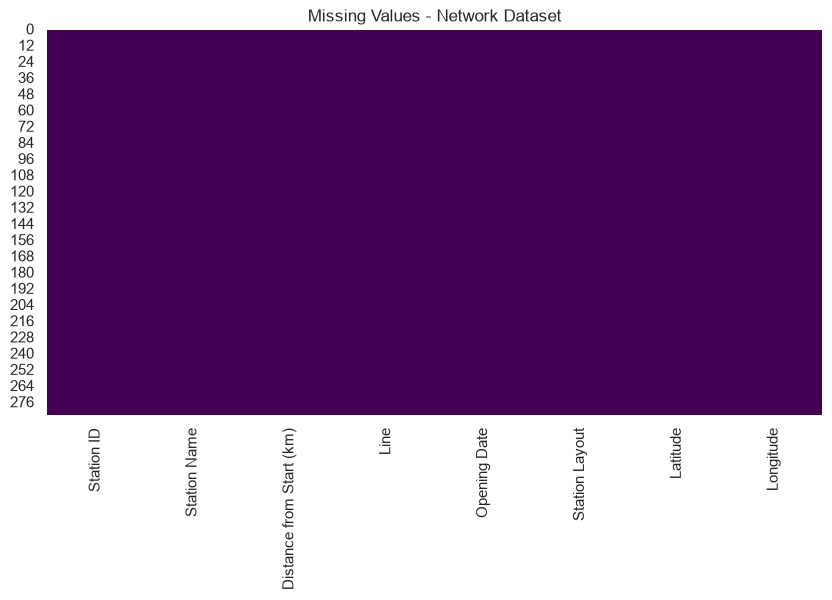

In [7]:
plt.figure(figsize=(10,5))

sns.heatmap(
    network_df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values - Network Dataset")
plt.show()

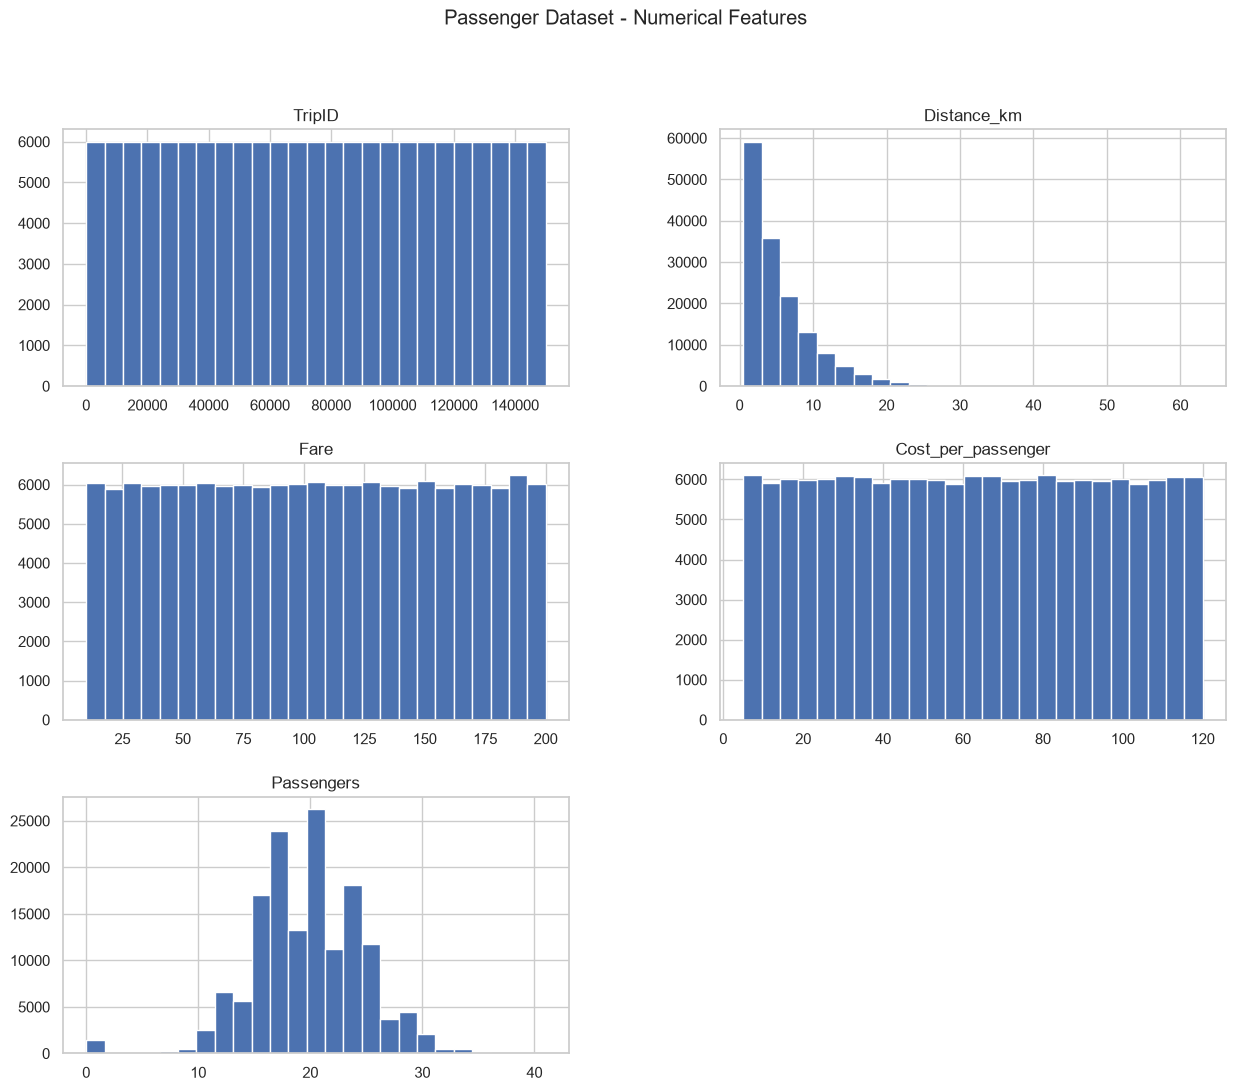

In [8]:
passenger_df.hist(
    figsize=(15,12),
    bins=25
)

plt.suptitle("Passenger Dataset - Numerical Features")
plt.show()

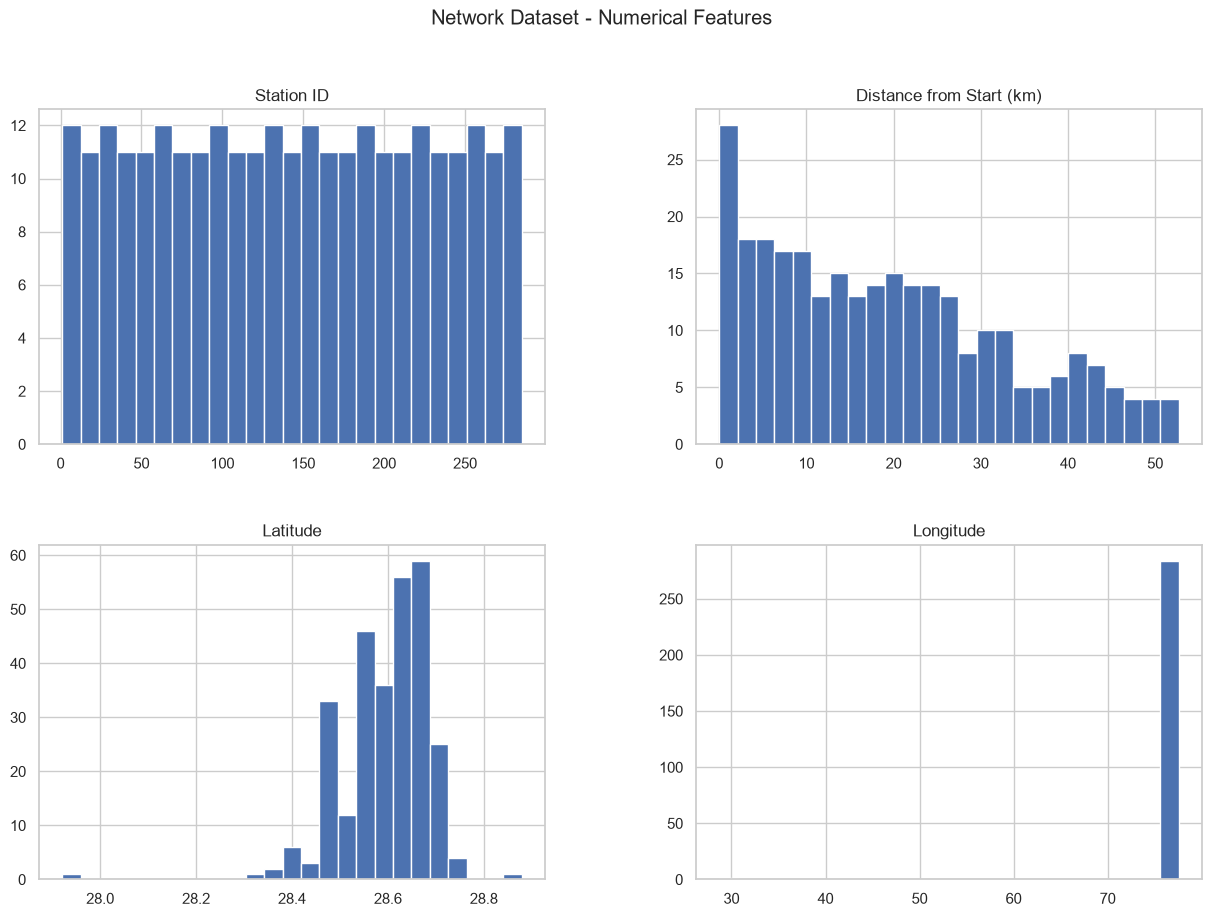

In [9]:
network_df.hist(
    figsize=(15,10),
    bins=25
)

plt.suptitle("Network Dataset - Numerical Features")
plt.show()

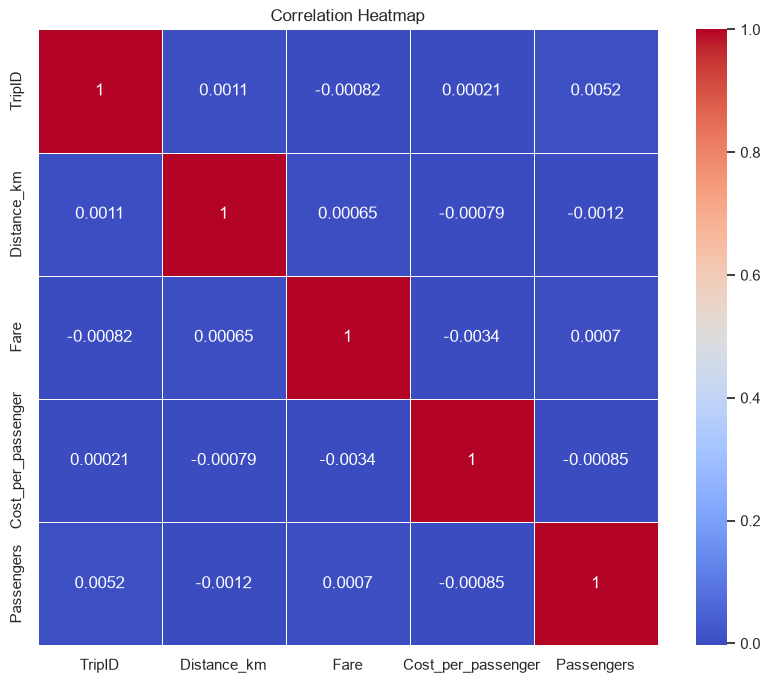

In [10]:
plt.figure(figsize=(10,8))

corr = passenger_df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

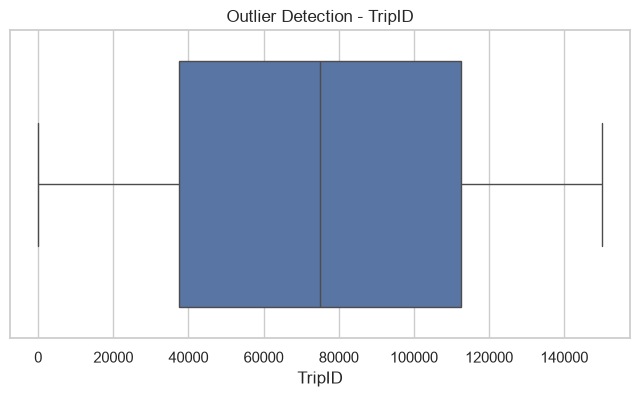

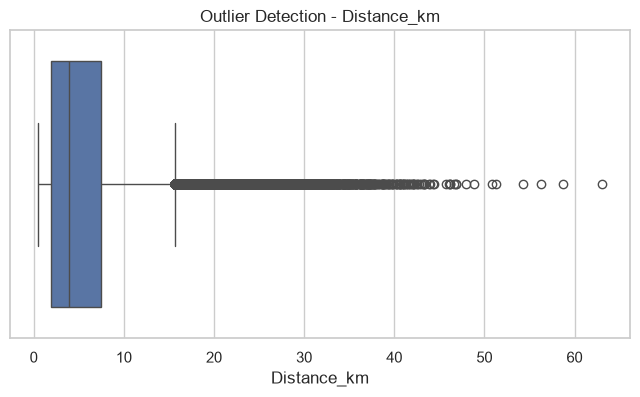

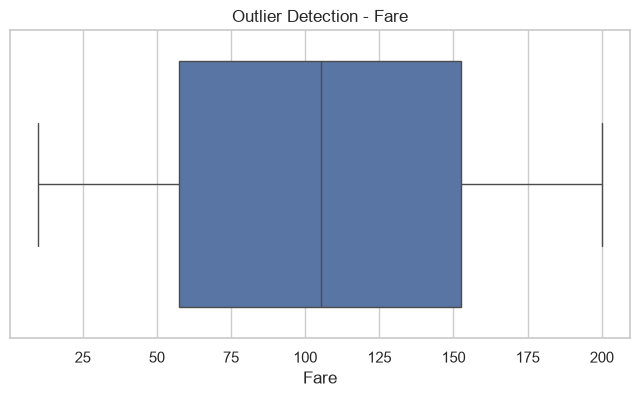

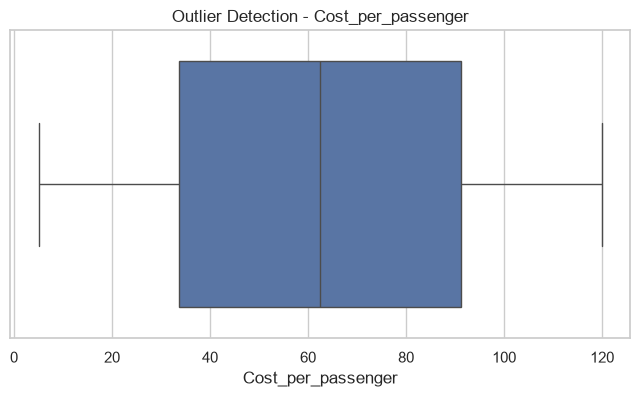

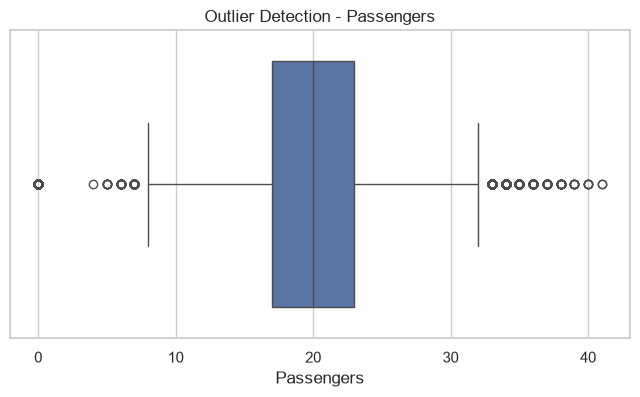

In [11]:
numeric_cols = passenger_df.select_dtypes(include=np.number).columns

for col in numeric_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=passenger_df[col])

    plt.title(f"Outlier Detection - {col}")

    plt.show()

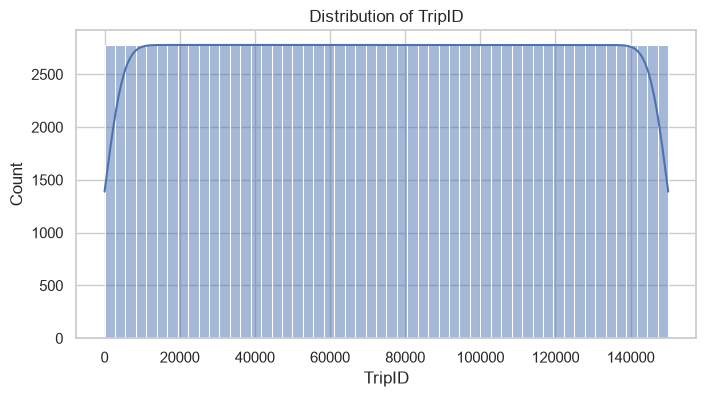

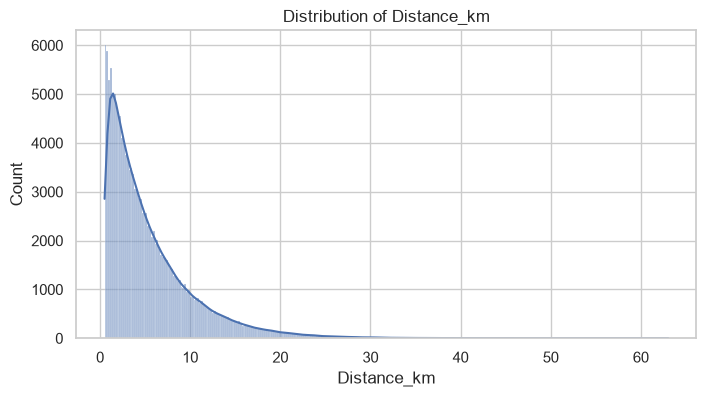

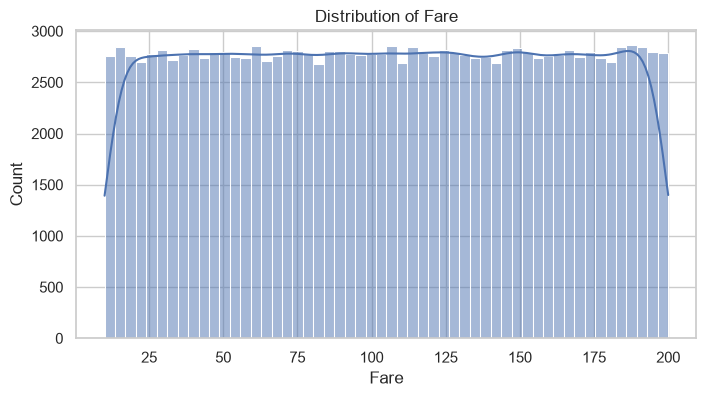

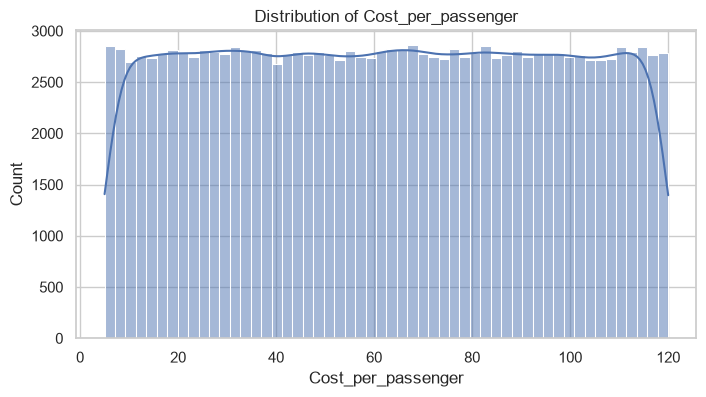

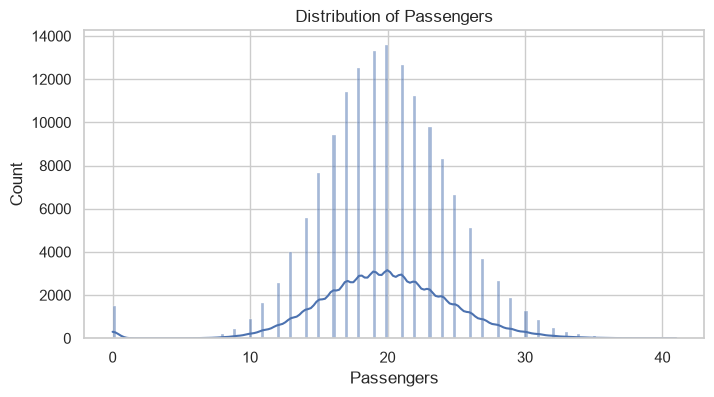

In [12]:
for col in numeric_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(
        passenger_df[col],
        kde=True
    )

    plt.title(f"Distribution of {col}")

    plt.show()

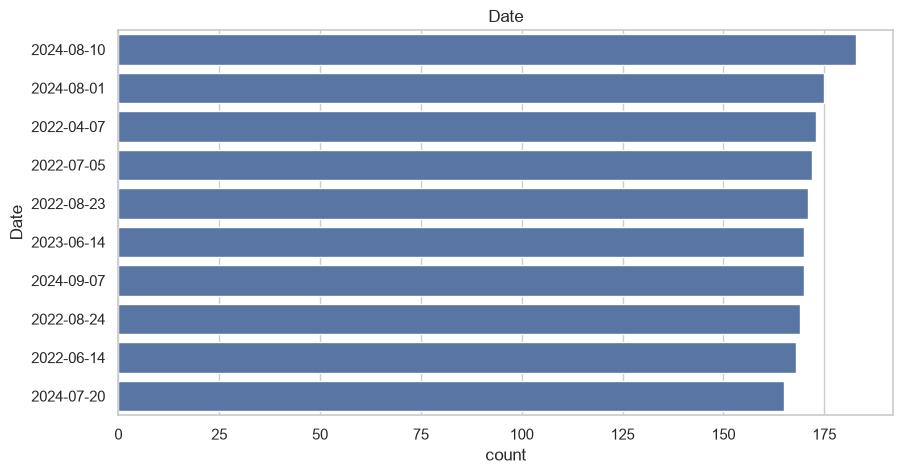

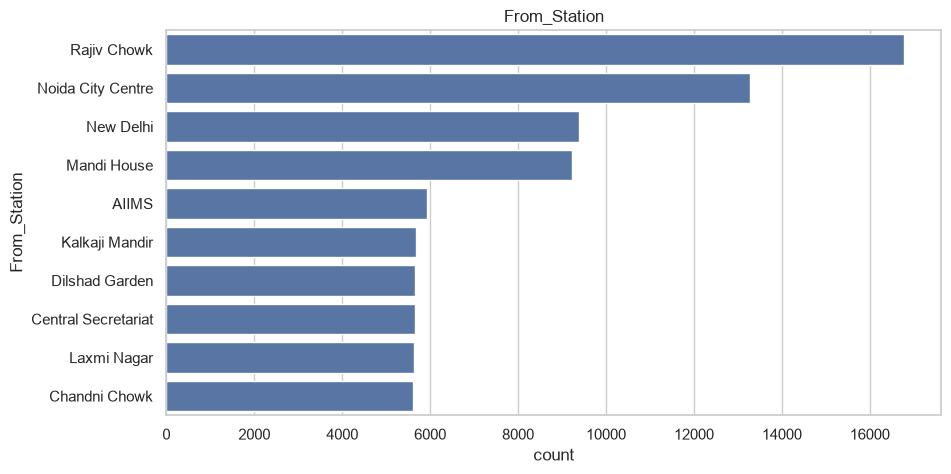

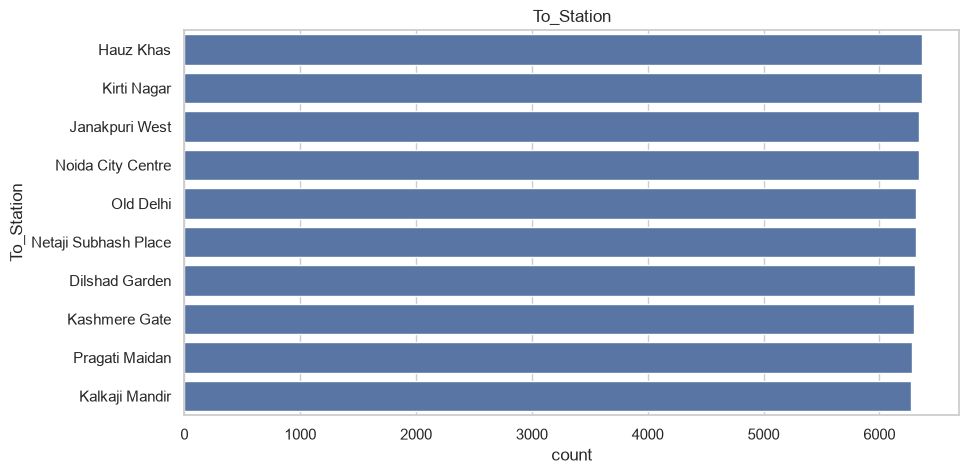

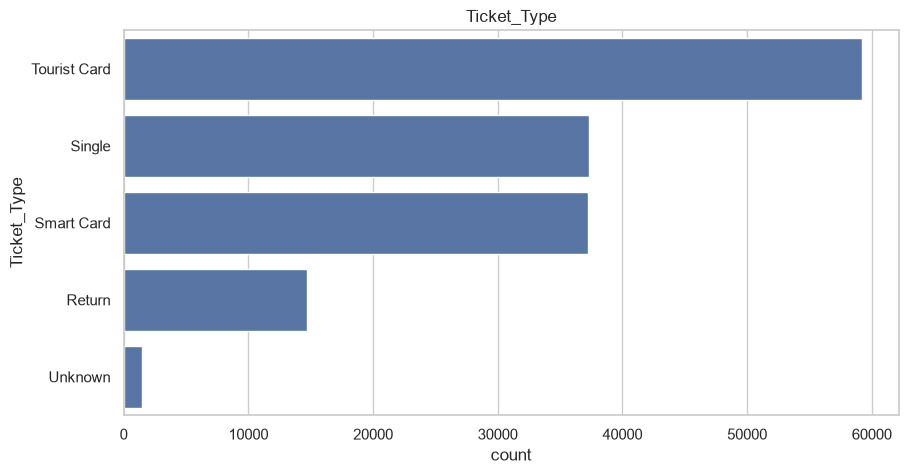

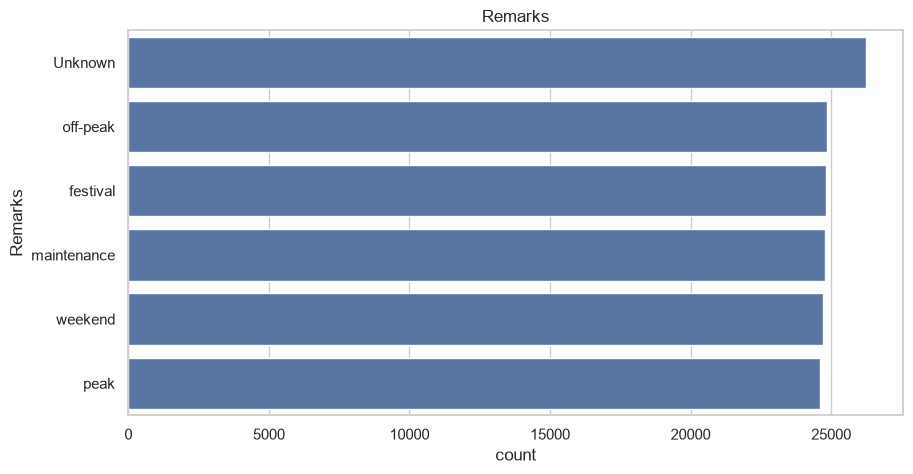

In [13]:
cat_cols = passenger_df.select_dtypes(include="object").columns

for col in cat_cols:

    plt.figure(figsize=(10,5))

    sns.countplot(
        y=passenger_df[col],
        order=passenger_df[col].value_counts().index[:10]
    )

    plt.title(col)

    plt.show()

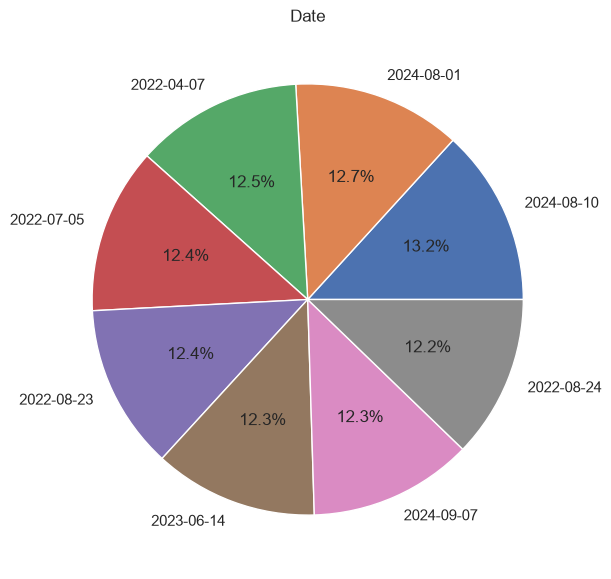

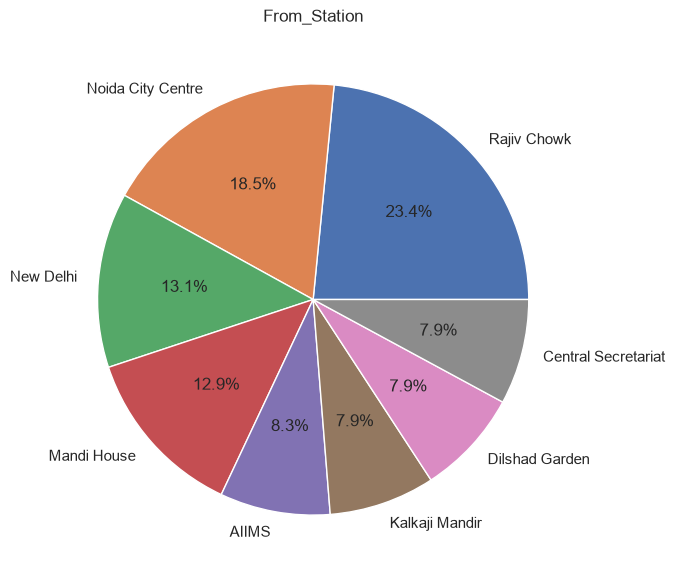

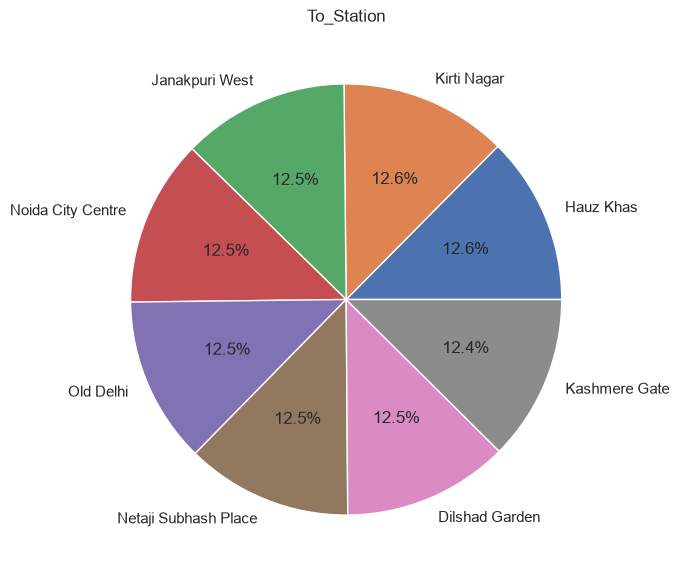

In [14]:
for col in cat_cols[:3]:

    plt.figure(figsize=(7,7))

    passenger_df[col].value_counts().head(8).plot(
        kind="pie",
        autopct="%1.1f%%"
    )

    plt.ylabel("")

    plt.title(col)

    plt.show()

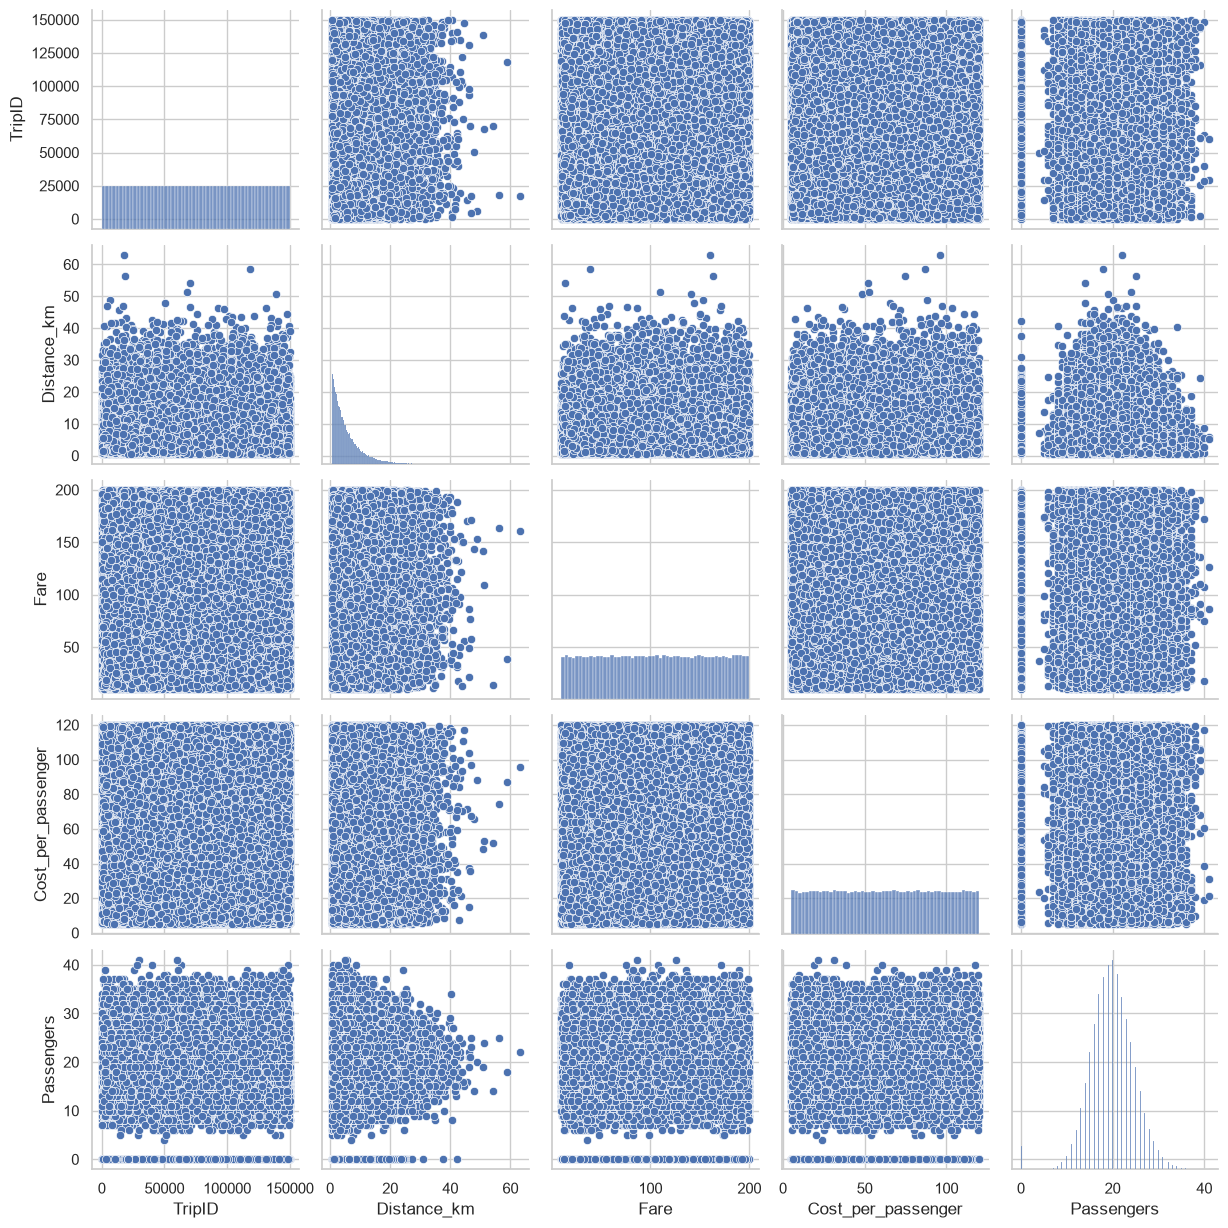

In [15]:
sns.pairplot(
    passenger_df.select_dtypes(include=np.number)
)

plt.show()

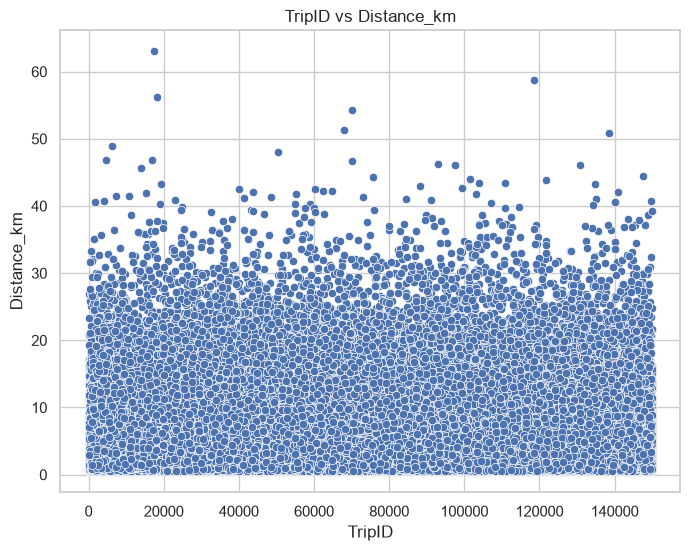

In [16]:
num_cols = passenger_df.select_dtypes(include=np.number).columns

if len(num_cols) >= 2:

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        x=passenger_df[num_cols[0]],
        y=passenger_df[num_cols[1]]
    )

    plt.title(f"{num_cols[0]} vs {num_cols[1]}")

    plt.show()

In [17]:
for col in cat_cols:

    print("="*60)

    print(col)

    print(passenger_df[col].value_counts())

    print()

Date
Date
2024-08-10    183
2024-08-01    175
2022-04-07    173
2022-07-05    172
2022-08-23    171
             ... 
2024-11-16    107
2022-08-13    106
2023-08-03    104
2023-11-27     99
2023-02-10     98
Name: count, Length: 1095, dtype: int64

From_Station
From_Station
Rajiv Chowk          16789
Noida City Centre    13267
New Delhi             9395
Mandi House           9237
AIIMS                 5923
                     ...  
BARAKHAMBA ROAD        130
old delhi              127
barakhamba road        111
punjabi bagh           110
pragati maidan         107
Name: count, Length: 71, dtype: int64

To_Station
To_Station
Hauz Khas               6372
Kirti Nagar             6371
Janakpuri West          6340
Noida City Centre       6338
Old Delhi               6313
Netaji Subhash Place    6312
Dilshad Garden          6306
Kashmere Gate           6295
Pragati Maidan          6282
Kalkaji Mandir          6273
Barakhamba Road         6255
Rajouri Garden          6253
Central Secretariat

In [18]:
print("EDA Completed Successfully!")

print("-"*50)

print(f"Passenger Dataset Rows : {passenger_df.shape[0]}")

print(f"Passenger Dataset Columns : {passenger_df.shape[1]}")

print(f"Network Dataset Rows : {network_df.shape[0]}")

print(f"Network Dataset Columns : {network_df.shape[1]}")

print("-"*50)

EDA Completed Successfully!
--------------------------------------------------
Passenger Dataset Rows : 150000
Passenger Dataset Columns : 10
Network Dataset Rows : 285
Network Dataset Columns : 8
--------------------------------------------------
